In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from privacy_estimates.experiments.aml import JobList

/anaconda/envs/privacy-estimates/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# this is the non dp sweep pipeline
jobs = JobList.from_urls([
    'https://ml.azure.com/experiments/id/6b943575-e3c5-4fe0-8ec6-c102e72d929e/runs/HD_96626825-b496-47c7-806c-f114da697df4?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourceGroups/ppml/providers/Microsoft.MachineLearningServices/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47#hyperdriveOverview'])

In [16]:
id_to_results = {}

for child_job in jobs[0].aml_run.get_children():
    print(child_job.id)
    id_to_results[child_job.id] = child_job.get_metrics()

HD_96626825-b496-47c7-806c-f114da697df4_12
HD_96626825-b496-47c7-806c-f114da697df4_17
HD_96626825-b496-47c7-806c-f114da697df4_14
HD_96626825-b496-47c7-806c-f114da697df4_10
HD_96626825-b496-47c7-806c-f114da697df4_16
HD_96626825-b496-47c7-806c-f114da697df4_15
HD_96626825-b496-47c7-806c-f114da697df4_13
HD_96626825-b496-47c7-806c-f114da697df4_4
HD_96626825-b496-47c7-806c-f114da697df4_1
HD_96626825-b496-47c7-806c-f114da697df4_9
HD_96626825-b496-47c7-806c-f114da697df4_11
HD_96626825-b496-47c7-806c-f114da697df4_7
HD_96626825-b496-47c7-806c-f114da697df4_0
HD_96626825-b496-47c7-806c-f114da697df4_6
HD_96626825-b496-47c7-806c-f114da697df4_5
HD_96626825-b496-47c7-806c-f114da697df4_3
HD_96626825-b496-47c7-806c-f114da697df4_2
HD_96626825-b496-47c7-806c-f114da697df4_8


In [19]:
id_to_results['HD_96626825-b496-47c7-806c-f114da697df4_12']['eval_loss']

[4.1855621337890625,
 4.005002021789551,
 3.761603355407715,
 3.499387502670288,
 3.2222235202789307,
 3.0924463272094727,
 3.0340960025787354,
 2.9929146766662598,
 2.9468765258789062,
 2.9212329387664795,
 2.893707036972046,
 2.873324394226074,
 2.8571150302886963,
 2.8461225032806396,
 2.8365941047668457]

In [20]:
runid_2_hyperparams = {
    'HD_96626825-b496-47c7-806c-f114da697df4_0' : {"per_device_train_batch_size": 8, "learning_rate": 1e-06},
    'HD_96626825-b496-47c7-806c-f114da697df4_1' : {"per_device_train_batch_size": 8, "learning_rate": 4e-06},
    'HD_96626825-b496-47c7-806c-f114da697df4_10' : {"per_device_train_batch_size": 16, "learning_rate": 0.0003},
    'HD_96626825-b496-47c7-806c-f114da697df4_11' : {"per_device_train_batch_size": 16, "learning_rate": 0.001},
    'HD_96626825-b496-47c7-806c-f114da697df4_12' : {"per_device_train_batch_size": 32, "learning_rate": 1e-06}, 
    'HD_96626825-b496-47c7-806c-f114da697df4_13' : {"per_device_train_batch_size": 32, "learning_rate": 4e-06},
    'HD_96626825-b496-47c7-806c-f114da697df4_14' : {"per_device_train_batch_size": 32, "learning_rate": 2e-05},
    'HD_96626825-b496-47c7-806c-f114da697df4_15' : {"per_device_train_batch_size": 32, "learning_rate": 6e-05},
    'HD_96626825-b496-47c7-806c-f114da697df4_16' : {"per_device_train_batch_size": 32, "learning_rate": 0.0003},
    'HD_96626825-b496-47c7-806c-f114da697df4_17' : {"per_device_train_batch_size": 32, "learning_rate": 0.001},
    'HD_96626825-b496-47c7-806c-f114da697df4_2' : {"per_device_train_batch_size": 8, "learning_rate": 2e-05},
    'HD_96626825-b496-47c7-806c-f114da697df4_3' : {"per_device_train_batch_size": 8, "learning_rate": 6e-05},
    'HD_96626825-b496-47c7-806c-f114da697df4_4' : {"per_device_train_batch_size": 8, "learning_rate": 0.0003},
    'HD_96626825-b496-47c7-806c-f114da697df4_5' : {"per_device_train_batch_size": 8, "learning_rate": 0.001},
    'HD_96626825-b496-47c7-806c-f114da697df4_6' : {"per_device_train_batch_size": 16, "learning_rate": 1e-06},
    'HD_96626825-b496-47c7-806c-f114da697df4_7' : {"per_device_train_batch_size": 16, "learning_rate": 4e-06},
    'HD_96626825-b496-47c7-806c-f114da697df4_8' : {"per_device_train_batch_size": 16, "learning_rate": 2e-05},
    'HD_96626825-b496-47c7-806c-f114da697df4_9' : {"per_device_train_batch_size": 16, "learning_rate": 6e-05}
}

hyperparams_2_runid = {sum(v.values()): k for k, v in runid_2_hyperparams.items()}

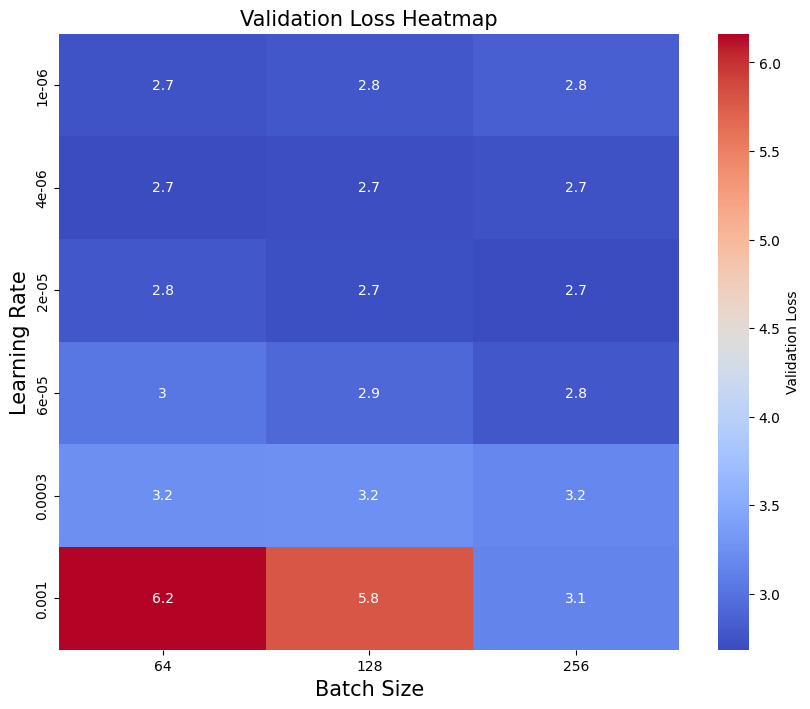

In [32]:
learning_rates = [1e-06, 4e-06, 2e-05, 6e-05, 0.0003, 0.001]
batch_sizes = [8, 16, 32]
effective_batch_size = [k * 8 for k in batch_sizes]
val_losses = []

for lr in learning_rates:
    lr_vals = []
    for bs in batch_sizes:
        runid = hyperparams_2_runid[lr + bs]
        last_val_loss = id_to_results[runid]['eval_loss'][-1]
        lr_vals.append(last_val_loss)
    val_losses.append(lr_vals)


plt.figure(figsize=(10, 8))
sns.heatmap(val_losses, xticklabels=effective_batch_size, yticklabels=learning_rates,  annot=True, cmap='coolwarm', 
            cbar_kws={'label': 'Validation Loss'})
plt.xlabel('Batch Size', fontsize = 15)
plt.ylabel('Learning Rate', fontsize = 15)
plt.title('Validation Loss Heatmap', fontsize = 15)
plt.show()


In [35]:
id_to_results['HD_96626825-b496-47c7-806c-f114da697df4_8']['eval_loss']

[2.88368821144104,
 2.7808547019958496,
 2.7644574642181396,
 2.7266364097595215,
 2.717768430709839,
 2.7222697734832764,
 2.7255871295928955,
 2.698394775390625,
 2.704035520553589,
 2.6913585662841797,
 2.6939730644226074,
 2.7040228843688965,
 2.6902151107788086,
 2.6902220249176025,
 2.686389923095703,
 2.6817800998687744,
 2.6718242168426514,
 2.6958820819854736,
 2.6880762577056885,
 2.681859254837036,
 2.684635877609253,
 2.6950459480285645,
 2.702082872390747,
 2.691415786743164,
 2.710127353668213,
 2.6925182342529297,
 2.697763442993164,
 2.7015514373779297,
 2.7232420444488525,
 2.710172653198242,
 2.712315082550049]

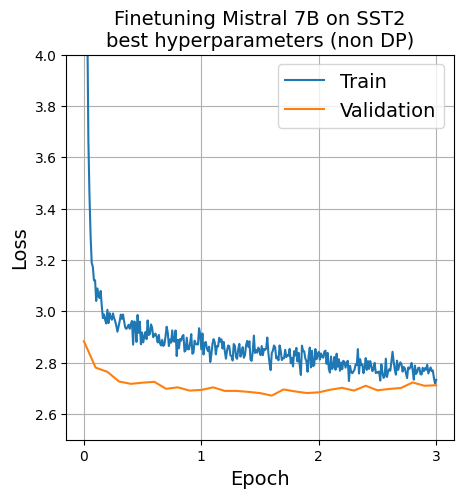

In [42]:
best_job = id_to_results['HD_96626825-b496-47c7-806c-f114da697df4_8']

plt.figure(figsize=(5,5))

plt.plot(np.linspace(0, 3, len(best_job['loss'])), best_job['loss'], label='Train')
plt.plot(np.linspace(0, 3, len(best_job['eval_loss'])), best_job['eval_loss'], label='Validation')
plt.xticks([0, 1, 2, 3], [0, 1, 2, 3])
plt.legend(fontsize=14)
plt.grid()
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.ylim(2.5, 4)
plt.title('Finetuning Mistral 7B on SST2\nbest hyperparameters (non DP)', fontsize=14)
plt.show()